# Go MPC (Python Wrapper)

This notebook runs the Go implementation and then plots outputs from CSV files.


In [1]:
# %%
%load_ext autoreload
%autoreload 2
import os
import subprocess
import shutil
from pathlib import Path
import json
import numpy as np
from scipy.signal import cont2discrete


### Offline Phase (`GoVempc/cmd/ckks_offline/main.go`)
Implements Algorithm 1


In [2]:
# Set configuration

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
out = ROOT / "output"
out.mkdir(parents=True, exist_ok=True)

cfg = {
    "m": 0.2,
    "l": 0.5,
    "g": 9.81,
    "dt": 0.05,
    "N": 10, # MPC horizon
    "QDiag": [50.0, 5.0],
    "RDiag": [0.1],
    "QfScale": 2.0,
    # Initial condition
    "x0": [0.3, 0.1],
    # Constraints
    "thetaMax": 0.5,
    "omegaMax": 0.8,
    "uMax": 1.0,
    # Variational mpc parameters
    "sigma0": 0.25,
    "lambda": 0.1,
    # Encryption paramters
    "logN": 13,
    "logQ": [30, 30, 30, 30],
    "logP": [30],
    "logDefaultScale": 40,
    # Number of total samples
    "K": 240,
    "nWorkers": 4,
    # K_chunk = 60
    # "K": 60,
    # "nWorkers": 1,
    # Simulation timesteps
    "T": 200,
    "chebOrder": 10,
    "chebBound": 5.0,
    "chebEta": 500.0
}
(out / "ckks_config.json").write_text(json.dumps(cfg, indent=2))
print("Wrote", out / "ckks_config.json")


Wrote c:\Users\user\OneDrive\Writing\2026\4 CDC Var Enc MPPI\Variational-Encrypted-Model-Predictive-Control\GoVempc\output\ckks_config.json


In [3]:
# Run offline procedure Algorithm 1
import json
import os
import subprocess
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")
# If your environment blocks proxy, uncomment:
# os.environ["GOPROXY"] = "direct"

cfg = json.loads((ROOT / "output" / "ckks_config.json").read_text())
print(f"Offline config: K={cfg['K']}, nWorkers={cfg.get('nWorkers', 1)}, K_chunk={cfg['K'] // cfg.get('nWorkers', 1)}")
print("Running: go run ./cmd/ckks_offline")
res = subprocess.run(["go", "run", "./cmd/ckks_offline"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0 and res.stderr:
    print(res.stderr)


# With K=60, N_worker = 1 took
# Client offline time: 682.772 ms
# Cloud offline time: 26693.415 ms
# With K=240, N_worker = 4 took
# Client offline time: 669.994 ms
# Cloud offline time: 33836.844 ms
# Not exactly scalable but almost same

Offline config: K=240, nWorkers=4, K_chunk=60
Running: go run ./cmd/ckks_offline
A =
⎡1.0246254099832466  0.05040975363090225⎤
  ⎣0.9890393662383021   1.0246254099832466⎦
B =
⎡0.025102354722983437⎤
  ⎣  1.0081950726180449⎦
Slot width: 60, slots needed per worker: 3600
CKKS slots: 4096
L_U dims: 10x10
Gamma dims: 60x10
CKKS slots: 4096, K: 240, nWorkers: 4, K_chunk: 60, T: 200
Cache Enc(L_U * xi): T=200, workers=4, packed=60 samples per ct
Cache Enc(Gamma * xi): T=200, workers=4, packed=60 samples per ct
Client offline time: 644.199 ms
Cloud offline time: 1318979.915 ms



### Online Phase (`GoVempc/cmd/ckks_online/main.go`)
Implements Algorithm 2


In [4]:
# Run online procedure Algorithm 2
import json
import os
import subprocess
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_online").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")

cfg = json.loads((ROOT / "output" / "ckks_config.json").read_text())
print(f"Online config: K={cfg['K']}, nWorkers={cfg.get('nWorkers', 1)}, K_chunk={cfg['K'] // cfg.get('nWorkers', 1)}")

proc = subprocess.Popen(
    ["go", "run", "./cmd/ckks_online"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
if proc.stdout is not None:
    for line in proc.stdout:
        print(line, end="")
ret = proc.wait()
if ret != 0:
    print(f"Process exited with code {ret}")



Online config: K=240, nWorkers=4, K_chunk=60
step 0 cloud_ms 49.789
step 1 cloud_ms 48.611
step 2 cloud_ms 47.206
step 3 cloud_ms 46.684
step 4 cloud_ms 45.643
step 5 cloud_ms 44.814
step 6 cloud_ms 45.052
step 7 cloud_ms 45.730
step 8 cloud_ms 45.952
step 9 cloud_ms 51.224
step 10 cloud_ms 48.004
step 11 cloud_ms 46.109
step 12 cloud_ms 51.960
step 13 cloud_ms 45.985
step 14 cloud_ms 46.209
step 15 cloud_ms 46.565
step 16 cloud_ms 44.850
step 17 cloud_ms 46.357
step 18 cloud_ms 48.768
step 19 cloud_ms 45.377
step 20 cloud_ms 46.621
step 21 cloud_ms 45.765
step 22 cloud_ms 46.222
step 23 cloud_ms 44.410
step 24 cloud_ms 44.519
step 25 cloud_ms 45.486
step 26 cloud_ms 47.640
step 27 cloud_ms 46.147
step 28 cloud_ms 44.885
step 29 cloud_ms 45.341
step 30 cloud_ms 44.953
step 31 cloud_ms 45.137
step 32 cloud_ms 43.590
step 33 cloud_ms 44.849
step 34 cloud_ms 46.837
step 35 cloud_ms 44.265
step 36 cloud_ms 45.215
step 37 cloud_ms 45.642
step 38 cloud_ms 46.044
step 39 cloud_ms 44.936
step 

In [5]:
# Unencrypted variational MPC
import os
import json
import subprocess
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

# Locate GoVempc root

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "test").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")

cfg_path = ROOT / "output" / "ckks_config.json"
if not cfg_path.exists():
    raise FileNotFoundError("Missing output/ckks_config.json; run the config cell above first.")

print("Running: go run ./cmd/test")
res = subprocess.run(["go", "run", "./cmd/test"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0 and res.stderr:
    print(res.stderr)

cfg = json.loads(cfg_path.read_text())
dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

OUT = ROOT / "output"
xs_var = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_var = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)



Running: go run ./cmd/test
Standard MPC
  runtime: 17ms
  cost:    34.237410
  viol:    (x=0.000000, u=0.000123)
Variational MPC
  runtime: 58ms
  cost:    34.476757
  viol:    (x=0.000000, u=0.000000)
  w_sum mean: 238.650000
  accept mean: 238.650000

Saved CSV outputs to output
Saved plots to output\plots



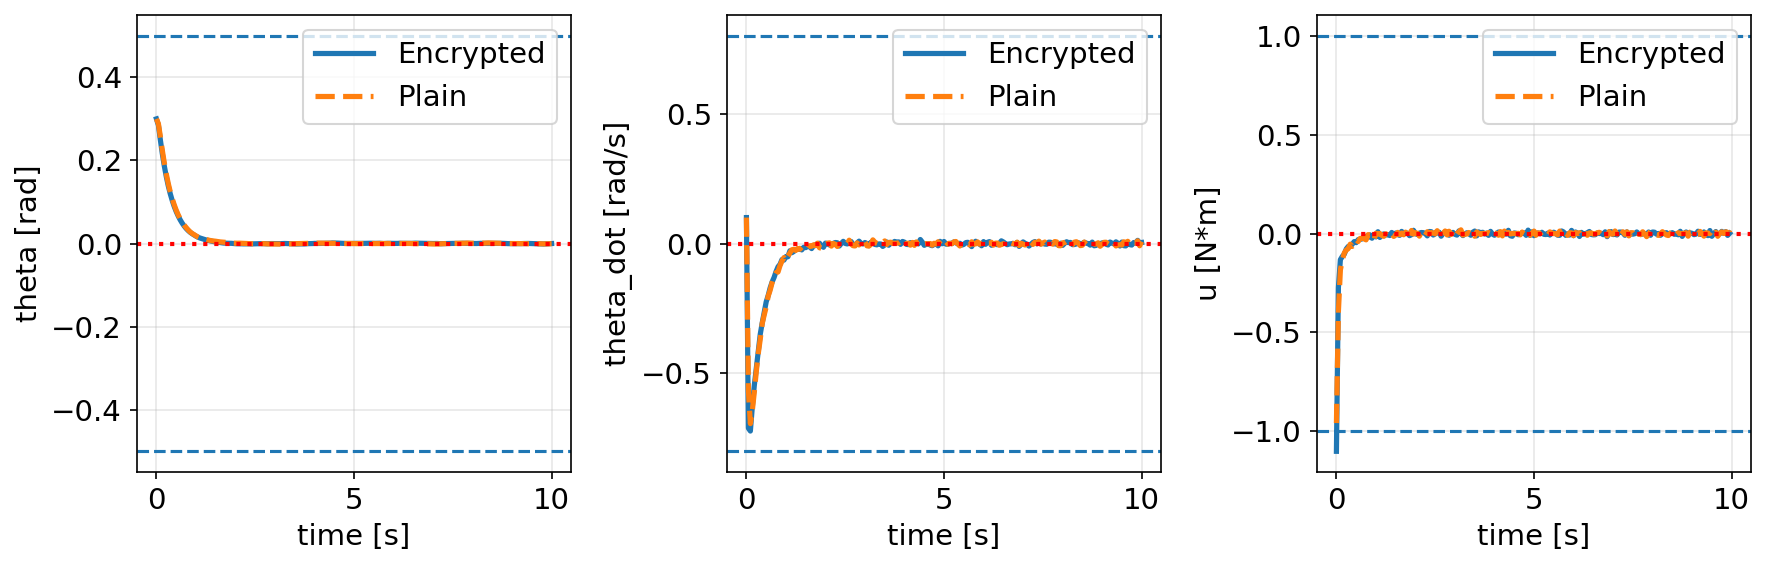

Saved overlay plot to C:\Users\user\OneDrive\Writing\2026\4 CDC Var Enc MPPI\Variational-Encrypted-Model-Predictive-Control\GoVempc\output\overlay_plot.png


In [6]:
# Overlay encrypted vs plain variational MPC results
import json
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pathlib import Path

OUT = Path("output")
cfg = json.loads((OUT / "ckks_config.json").read_text())

dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

xs_ckks = np.loadtxt(OUT / "xs_ckks.csv", delimiter=",", ndmin=2)
us_ckks = np.loadtxt(OUT / "us_ckks.csv", delimiter=",", ndmin=2)
xs_plain = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_plain = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)

t_ckks = np.arange(xs_ckks.shape[0]) * dt
t_plain = np.arange(xs_plain.shape[0]) * dt
tu_ckks = np.arange(us_ckks.shape[0]) * dt
tu_plain = np.arange(us_plain.shape[0]) * dt

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
ax = ax.ravel()

def add_bounds(a, bound):
    a.axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    a.axhline(+bound, linestyle="--")
    a.axhline(-bound, linestyle="--")

# theta
ax[0].plot(t_ckks, xs_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[0].plot(t_plain, xs_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[0], theta_max)
ax[0].set_ylabel("theta [rad]")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# theta_dot
ax[1].plot(t_ckks, xs_ckks[:, 1], label="Encrypted", linewidth=2.5)
ax[1].plot(t_plain, xs_plain[:, 1], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[1], omega_max)
ax[1].set_ylabel("theta_dot [rad/s]")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

# u
ax[2].plot(tu_ckks, us_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[2].plot(tu_plain, us_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[2], u_max)
ax[2].set_ylabel("u [N*m]")
ax[2].grid(True, alpha=0.3)
ax[2].legend()

for a in ax:
    a.set_xlabel("time [s]")

plt.tight_layout()
plot_path = OUT / "overlay_plot.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(plot_path)))
print(f"Saved overlay plot to {plot_path.resolve()}")


In [7]:
# # Save a portable snapshot for upload/replot in future sessions
# snapshot_path = OUT / "overlay_snapshot.npz"

# np.savez_compressed(
#     snapshot_path,
#     dt=np.array([dt], dtype=float),
#     theta_max=np.array([theta_max], dtype=float),
#     omega_max=np.array([omega_max], dtype=float),
#     u_max=np.array([u_max], dtype=float),
#     xs_ckks=xs_ckks,
#     us_ckks=us_ckks,
#     xs_plain=xs_plain,
#     us_plain=us_plain,
#     t_ckks=t_ckks,
#     t_plain=t_plain,
#     tu_ckks=tu_ckks,
#     tu_plain=tu_plain,
# )

# print(f"Saved snapshot: {snapshot_path.resolve()}")
# print("Reload with: data = np.load(snapshot_path)")


In [8]:
# # Reload saved snapshot and replot overlay

# import tikzplotlib

# import os
# from pathlib import Path
# import numpy as np
# import matplotlib.pyplot as plt

# def find_root(start: Path) -> Path:
#     for p in [start] + list(start.parents):
#         if (p / "go.mod").exists() and (p / "cmd" / "test").exists():
#             return p
#         if (p / "GoVempc" / "go.mod").exists():
#             return p / "GoVempc"
#     return start

# ROOT = find_root(Path.cwd())
# os.chdir(ROOT)

# OUT = ROOT / "output"
# snapshot_path = OUT / "overlay_snapshot.npz"
# if not snapshot_path.exists():
#     raise FileNotFoundError(
#         f"Missing {snapshot_path}; run the snapshot save cell first."
#     )

# with np.load(snapshot_path) as data:
#     dt = float(data["dt"][0])
#     theta_max = float(data["theta_max"][0])
#     omega_max = float(data["omega_max"][0])
#     u_max = float(data["u_max"][0])
#     xs_ckks = data["xs_ckks"]
#     us_ckks = data["us_ckks"]
#     xs_plain = data["xs_plain"]
#     us_plain = data["us_plain"]
#     t_ckks = data["t_ckks"] if "t_ckks" in data else np.arange(xs_ckks.shape[0]) * dt
#     t_plain = data["t_plain"] if "t_plain" in data else np.arange(xs_plain.shape[0]) * dt
#     tu_ckks = data["tu_ckks"] if "tu_ckks" in data else np.arange(us_ckks.shape[0]) * dt
#     tu_plain = data["tu_plain"] if "tu_plain" in data else np.arange(us_plain.shape[0]) * dt

# print(f"Loaded snapshot: {snapshot_path.resolve()}")
# print(f"Shapes: xs_ckks={xs_ckks.shape}, xs_plain={xs_plain.shape}, us_ckks={us_ckks.shape}, us_plain={us_plain.shape}")

# plt.rcParams.update({"font.size": 14})
# fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
# ax = ax.ravel()

# def add_bounds(a, bound):
#     a.axhline(0.0, color="red", linestyle=":", linewidth=2.0)
#     a.axhline(+bound, linestyle="--")
#     a.axhline(-bound, linestyle="--")

# # theta
# ax[0].plot(t_ckks, xs_ckks[:, 0], label="Encrypted", linewidth=2.5)
# ax[0].plot(t_plain, xs_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
# add_bounds(ax[0], theta_max)
# ax[0].set_ylabel("theta [rad]")
# ax[0].grid(True, alpha=0.3)
# ax[0].legend()

# # theta_dot
# ax[1].plot(t_ckks, xs_ckks[:, 1], label="Encrypted", linewidth=2.5)
# ax[1].plot(t_plain, xs_plain[:, 1], label="Plain", linewidth=2.5, linestyle="--")
# add_bounds(ax[1], omega_max)
# ax[1].set_ylabel("theta_dot [rad/s]")
# ax[1].grid(True, alpha=0.3)
# ax[1].legend()

# # u
# ax[2].plot(tu_ckks, us_ckks[:, 0], label="Encrypted", linewidth=2.5)
# ax[2].plot(tu_plain, us_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
# add_bounds(ax[2], u_max)
# ax[2].set_ylabel("u [N*m]")
# ax[2].grid(True, alpha=0.3)
# ax[2].legend()

# for a in ax:
#     a.set_xlabel("time [s]")

# plt.tight_layout()
# tikzplotlib.save("tikz.tex")

# # TODO: Tell me how to save this plot as a tikz tex